# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [14]:
chipo = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep='\t')

### Step 4. See the first 10 entries

In [15]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

Text(0.5, 1.0, 'Most Ordered chipotle Items')

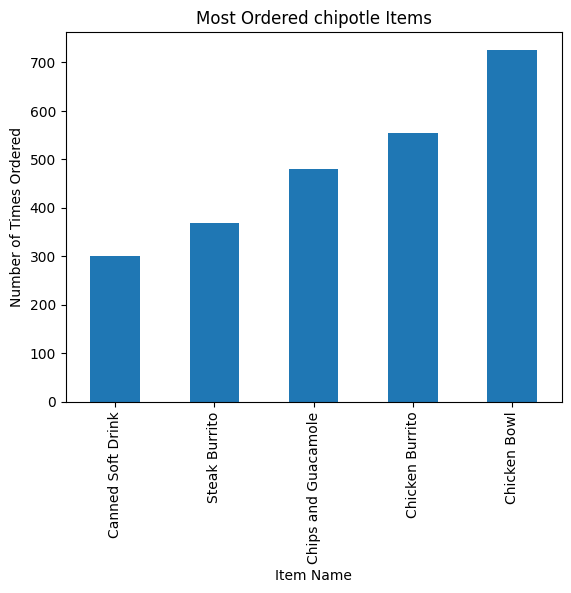

In [16]:
chipo.item_name.value_counts().head(5).sort_values(ascending=True).plot(kind='bar')
plt.xlabel('Item Name')
plt.ylabel('Number of Times Ordered')
plt.title('Most Ordered chipotle Items')

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

In [17]:
chipo['item_price'] = chipo.item_price.apply(lambda x: float(x[1:]))


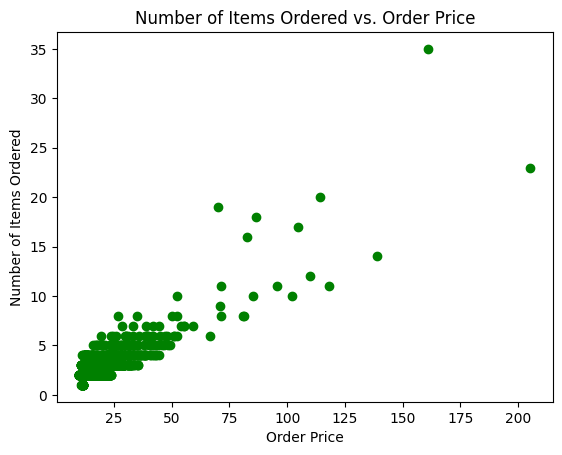

In [18]:
orders = chipo.groupby('order_id').agg(total_quantity=('quantity', 'sum'), total_price=('item_price', 'sum'))
plt.scatter(x=orders['total_price'], y=orders['total_quantity'], c='green')
plt.xlabel('Order Price')
plt.ylabel('Number of Items Ordered')
plt.title('Number of Items Ordered vs. Order Price')
plt.show()

### Step 7. BONUS: Top 5 order ids and their order price

Text(0.5, 1.0, 'Top 5 Order IDs and Their Order Price')

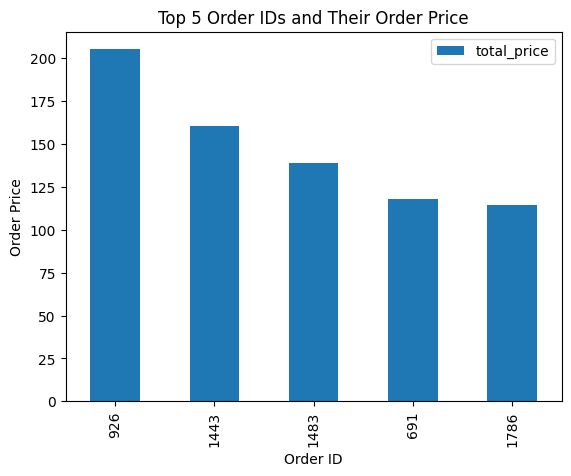

In [19]:
chipo.groupby('order_id').agg(total_price=('item_price', 'sum')).sort_values(by='total_price', ascending=False).head(5).plot(kind='bar')
plt.xlabel('Order ID')
plt.ylabel('Order Price')
plt.title('Top 5 Order IDs and Their Order Price')
